In [4]:
# Core scverse libraries
from __future__ import annotations

import anndata as ad

# Data retrieval
import pooch
import scanpy as sc

/home/leinehome/mh-hannover.local/ghahramm/envs/spatial/lib64/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
sc.settings.set_figure_params(dpi=50, facecolor="white")

In [6]:
EXAMPLE_DATA = pooch.create(
    path=pooch.os_cache("scverse_tutorials"),
    base_url="doi:10.6084/m9.figshare.22716739.v1/",
)
EXAMPLE_DATA.load_registry_from_doi()

In [7]:
samples = {
    "s1d1": "s1d1_filtered_feature_bc_matrix.h5",
    "s1d3": "s1d3_filtered_feature_bc_matrix.h5",
}
adatas = {}

for sample_id, filename in samples.items():
    path = EXAMPLE_DATA.fetch(filename)
    sample_adata = sc.read_10x_h5(path)
    sample_adata.var_names_make_unique()
    adatas[sample_id] = sample_adata

adata = ad.concat(adatas, label="sample")
adata.obs_names_make_unique()
print(adata.obs["sample"].value_counts())
adata

/home/leinehome/mh-hannover.local/ghahramm/envs/spatial/lib64/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/leinehome/mh-hannover.local/ghahramm/envs/spatial/lib64/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


sample
s1d1    8785
s1d3    8340
Name: count, dtype: int64


/home/leinehome/mh-hannover.local/ghahramm/envs/spatial/lib64/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/leinehome/mh-hannover.local/ghahramm/envs/spatial/lib64/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/leinehome/mh-hannover.local/ghahramm/envs/spatial/lib64/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


AnnData object with n_obs × n_vars = 17125 × 36601
    obs: 'sample'

In [8]:
adata.var["mt"] = adata.var_names.str.startswith("MT-")

adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))

adata.var["hb"] = adata.var_names.str.startswith(("^HB[^(P)]"))


In [9]:
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo", "hb"],  log1p=True, inplace=True)

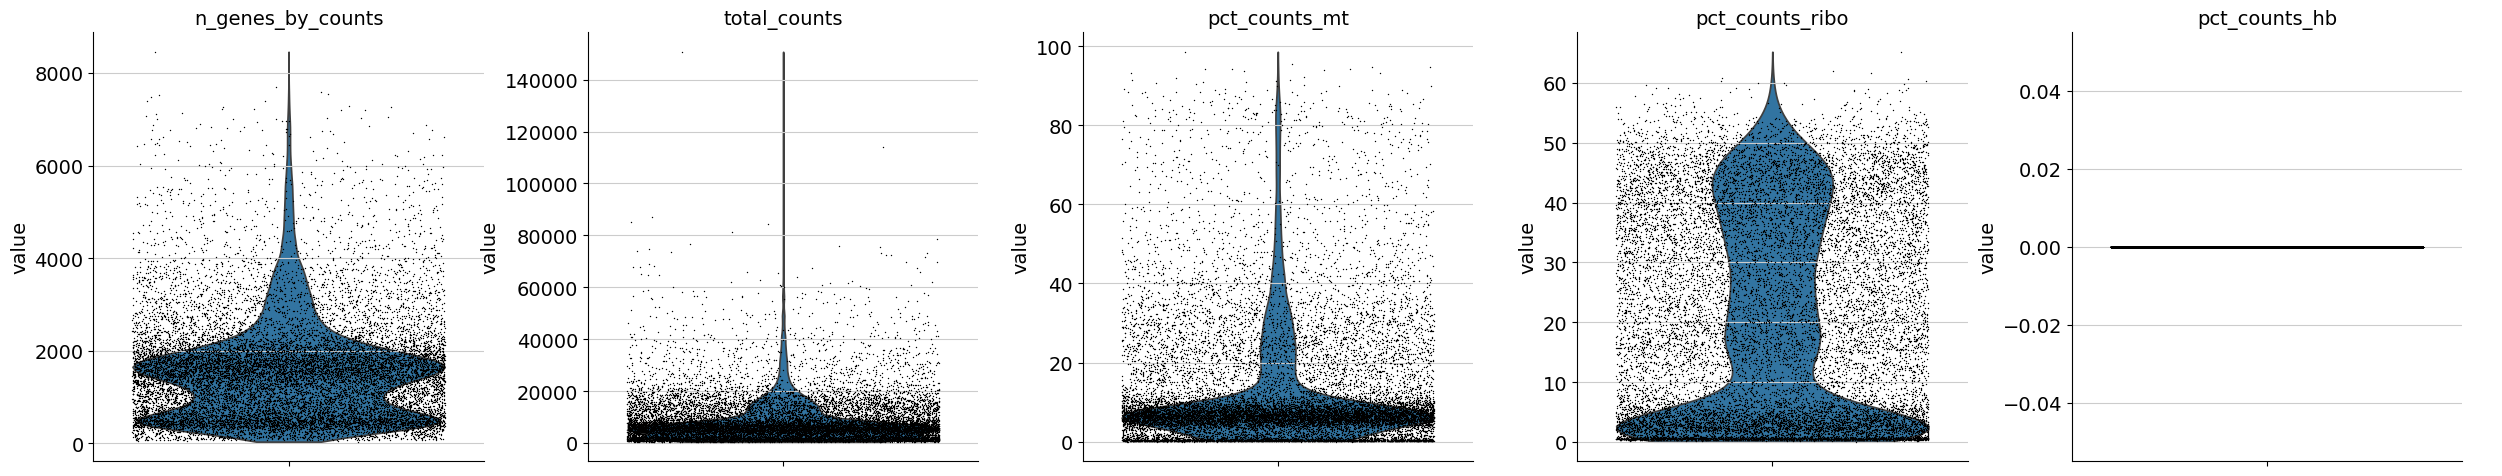

In [10]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt", "pct_counts_ribo", "pct_counts_hb"],
    jitter=0.4,
    multi_panel=True,
)

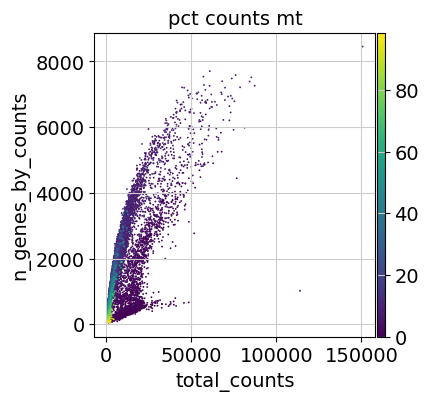

In [11]:
sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

In [12]:
sc.pp.filter_cells(adata, min_genes=100)
sc.pp.filter_genes(adata, min_cells=3)

In [13]:
sc.pp.scrublet(adata, batch_key="sample")

In [14]:
import scanpy as sc

In [15]:
%pip install scikit-image

Note: you may need to restart the kernel to use updated packages.


In [16]:
adata.layers["counts"] = adata.X.copy()

In [17]:
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

In [18]:
sc.pp.highly_variable_genes(adata, batch_key="sample", n_top_genes=2000)

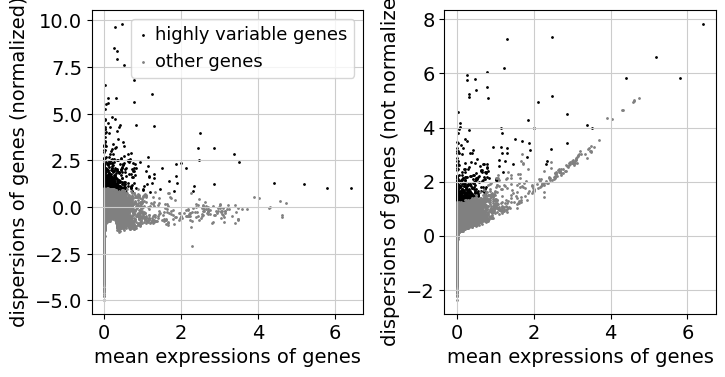

In [19]:
sc.pl.highly_variable_genes(adata)

In [ ]:
# Dimensionality reduction: scale, PCA, neighbors, UMAP (and optional t-SNE)
sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata, n_comps=50, use_highly_variable=True)
sc.pl.pca_variance_ratio(adata, log=True, n_pcs=50)

sc.pp.neighbors(adata, n_pcs=30, n_neighbors=15)
sc.tl.umap(adata)
sc.pl.umap(adata, color=["sample", "predicted_doublet"])

# optional: t-SNE
sc.tl.tsne(adata, n_pcs=30)
sc.pl.tsne(adata, color="sample")